# Micelle correction on/off, at the measured TDCR

A short, self-contained check: for each nuclide a **measured** triple-to-double
ratio is given, `L` is fitted to reproduce it twice — once with the micellar
correction and once without — and the two answers are compared.

This is how an activity measurement actually works. `L` is never imposed; it is
deduced from the ratio the counter reports. So the question is not "how much
light does the water remove" but **how wrong is the efficiency you report if
you deduce `L` with the wrong model**.

| | |
|---|---|
| Micelle diameter | 4 nm (the kernel uses the radius, 2 nm) |
| `sigma_micelle` | 0 — monodisperse |
| Aqueous fraction | 10 % water in Ultima Gold |
| Birks constant | 0.01 cm/MeV = 1e-5 cm/keV |
| MC trials | 10 000 |

| nuclide | measured TDCR |
|---|---|
| ³H | 0.668 |
| ⁵⁵Fe | 0.570 |
| ⁵¹Cr | 0.477 |
| ⁶³Ni | 0.881 |
| ¹⁴C | 0.970 |
| ⁹⁹Tc | 0.980 |

**Why most of the correction cancels.** If the correction were a uniform loss
of light, $f(E) = F$ at every energy, the uncorrected model would reproduce it
exactly with $L_{\text{uncorr}} = F\,L_{\text{corr}}$ — same photon budget per
decay, same efficiency. The two models would be **exactly degenerate** and
omitting the correction would cost nothing at all. The bulk dilution,
$1-f_{Aq}$, is of that kind.

What is left is the part where the retention *varies across the spectrum*: the
confinement region below ~3 keV, where the electron range is comparable to a
droplet. That is what this notebook measures.


In [1]:
import importlib, io, contextlib, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from importlib.metadata import version

import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.27


In [2]:
# ---- conditions --------------------------------------------------------
KB       = 1e-5         # cm/keV == 0.01 cm/MeV
V        = 10           # mL
N        = 10000        # MC trials -- raise once the picture is clear
FAQ      = 0.10         # aqueous volume fraction
DIAM     = 4            # nm, micelle DIAMETER (kernel uses radius = DIAM/2)
SIGMA    = 0.0          # monodisperse
COCKTAIL = 'Ultima Gold'

# Measured triple-to-double ratios.
TD_MEAS = {'H-3': 0.668, 'Fe-55': 0.570, 'Cr-51': 0.477,
           'Ni-63': 0.881, 'C-14': 0.970, 'Tc-99': 0.980}
NUCLIDES = list(TD_MEAS)

COLORS = {'H-3': '#d62728', 'Fe-55': '#ff7f0e', 'Cr-51': '#8c564b',
          'Ni-63': '#2ca02c', 'C-14': '#1f77b4', 'Tc-99': '#9467bd'}

# L grid for the fit. It stops at 20 on purpose: above roughly that the
# modelled TDCR turns over for the EC nuclides -- their escaping X-rays leave
# many near-zero deposits that the doubles recover long before the triples can
# -- so a search over a wider range can settle on the falling branch and return
# an L reproducing the wrong ratio. Staying on the rising branch avoids it.
L_GRID = np.logspace(np.log10(1.0), np.log10(20.0), 30)

NOMINAL = dict(fAq=tl.fAq, micCorr=tl.micCorr,
               diam=tl.diam_micelle, sigma=tl.sigma_micelle)


def set_state(micCorr):
    """Write the configuration and reload so the change takes effect.

    Since TDCRPy 2.20.22 the micelle kernel reads fAq, diam_micelle and
    sigma_micelle from the configuration on every call; the reload is still
    needed for the cocktail composition (density, Z, A), which is bound at
    import."""
    global tl, tm
    with contextlib.redirect_stdout(io.StringIO()):
        tl.modifyLScocktail(COCKTAIL, FAQ, 'Water', 0.0)
    tl.modifyDiam_micelle(DIAM)
    tl.modifySigma_micelle(SIGMA)
    tl.modifyMicCorr(bool(micCorr))
    tl = importlib.reload(tl)
    tm = importlib.reload(tm)


set_state(False)
print(f'{COCKTAIL} + {FAQ:.0%} water -> rho={tl.RHO:.4f} g/cm3, '
      f'Z={tl.Z:.4f}, A={tl.A:.4f}')
print(f'micelles: diameter {tl.diam_micelle} nm (radius '
      f'{tl.diam_micelle/2} nm), sigma {tl.sigma_micelle} nm')
print(f'kB = {KB} cm/keV, V = {V} mL, N = {N}')

Ultima Gold + 10% water -> rho=0.9818 g/cm3, Z=3.2597, A=5.9509
micelles: diameter 4.0 nm (radius 2.0 nm), sigma 0.0 nm
kB = 1e-05 cm/keV, V = 10 mL, N = 10000


## 1. Fitting `L` to each measured ratio

One Monte-Carlo pass per nuclide and arm, then the decay histories are replayed
across a grid of `L` — the same trick `eff()` uses internally, so the expensive
simulation happens once and the whole curve comes almost free. The fitted `L`
is where the modelled ratio crosses the measured one.

Keeping the whole curve rather than just the fitted point is what makes
section 2 possible.


In [3]:
curves, fit = {}, {}
t_start = time.time()
for rad in NUCLIDES:
    for mic in (False, True):
        t0 = time.time()
        set_state(mic)
        # eff() records one pass, fits L to the measured ratio, and since
        # TDCRPy 2.20.23 returns u_L -- the Monte-Carlo uncertainty of that
        # fitted L, from the counting uncertainty of the modelled ratio
        # divided by the local slope d(T/D)/dL. That slope is what matters
        # here: near saturation the ratio is almost flat in L, so inverting it
        # amplifies noise and u_L becomes large. Reading Delta_L without it
        # would be reading noise.
        r = tm.eff(TD_MEAS[rad], rad, '1', KB, V, N=N, L=2.0,
                   Lbounds=(float(L_GRID[0]), float(L_GRID[-1])))
        L_fit, uL, D_fit, uD_fit = r[0], r[16], r[4], r[5]
        tdcr_fit = r[6] / r[4] if r[4] > 0 else np.nan

        # The curve, replayed from the histories eff() has just recorded --
        # no second simulation.
        td, ed = [], []
        for Lg in L_GRID:
            o = tm.TDCRPy(Lg, rad, '1', N, KB, V, readRecHist=True)
            td.append(o[4] / o[2] if o[2] > 0 else np.nan)
            ed.append(o[2])
        curves[(rad, mic)] = dict(tdcr=np.array(td), effD=np.array(ed))

        ok = abs(tdcr_fit - TD_MEAS[rad]) < 1e-3
        fit[(rad, mic)] = dict(L=L_fit, uL=uL, D=D_fit, uD=uD_fit, ok=ok)
        print(f'{rad:6s} micCorr={str(mic):5s}  L = {L_fit:7.4f} +- {uL:.4f}  '
              f'eff_D = {D_fit:.5f} +- {uD_fit:.5f}  '
              f'(fitted TDCR {tdcr_fit:.5f})'
              f'{"" if ok else "   *** FIT DID NOT CONVERGE ***"}'
              f'   [{time.time()-t0:.0f} s]', flush=True)

bad = [k for k, v in fit.items() if not v['ok']]
print(f'\ntotal {time.time()-t_start:.0f} s')
print('All fits reproduce their measured ratio.' if not bad
      else f'NOT CONVERGED, results meaningless for: {bad}')

H-3    micCorr=False  L =  6.0655 +- 0.0581  eff_D = 0.70040 +- 0.00342  (fitted TDCR 0.66800)   [23 s]


H-3    micCorr=True   L =  6.7424 +- 0.0633  eff_D = 0.69645 +- 0.00347  (fitted TDCR 0.66800)   [36 s]


Fe-55  micCorr=False  L =  5.5959 +- 0.0032  eff_D = 0.79603 +- 0.00277  (fitted TDCR 0.57000)   [149 s]


Fe-55  micCorr=True   L =  6.5219 +- 0.0057  eff_D = 0.79698 +- 0.00276  (fitted TDCR 0.57000)   [242 s]


Cr-51  micCorr=False  L =  5.5881 +- 0.0108  eff_D = 0.73691 +- 0.00242  (fitted TDCR 0.47700)   [152 s]


...

C-14   micCorr=False  L =  6.1721 +- 0.2252  eff_D = 0.96164 +- 0.00164  (fitted TDCR 0.97000)   [19 s]


C-14   micCorr=True   L =  6.8338 +- 0.2371  eff_D = 0.96183 +- 0.00164  (fitted TDCR 0.97000)   [25 s]


Tc-99  micCorr=False  L =  4.7680 +- 0.2170  eff_D = 0.97579 +- 0.00130  (fitted TDCR 0.98000)   [19 s]


Tc-99  micCorr=True   L =  5.6639 +- 0.2754  eff_D = 0.97325 +- 0.00139  (fitted TDCR 0.98000)   [28 s]



total 986 s
All fits reproduce their measured ratio.


## 2. The result: same measured ratio, two efficiencies

Each curve is a nuclide's model with `L` running along it, plotted as
efficiency against the ratio a counter would report. The vertical dotted line
is the **measured** ratio, and the two markers are where each model says the
efficiency is.

Because both arms are pinned to the *same* measurement, the comparison is read
**vertically**: the gap between the circle and the square is the whole effect,
with no `L` left in it.

If the correction were a pure rescaling of the light, the two curves would lie
on top of one another — the corrected model would just sit at a different `L`
on the same curve. Any visible separation is the part that no refit can absorb.


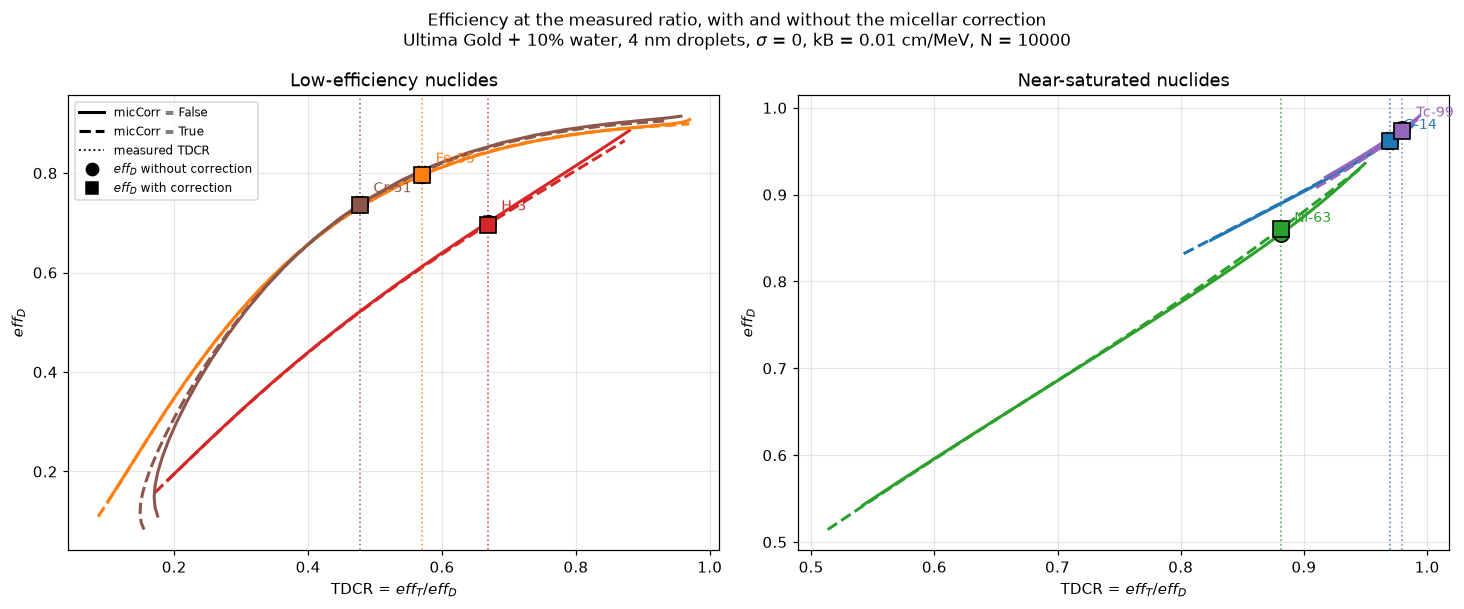

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
for ax, group, title in (
        (axes[0], ['H-3', 'Fe-55', 'Cr-51'], 'Low-efficiency nuclides'),
        (axes[1], ['Ni-63', 'C-14', 'Tc-99'], 'Near-saturated nuclides')):
    for rad in group:
        for mic, ls in ((False, '-'), (True, '--')):
            c = curves[(rad, mic)]
            ax.plot(c['tdcr'], c['effD'], ls, color=COLORS[rad], lw=2.0)
        ax.axvline(TD_MEAS[rad], color=COLORS[rad], ls=':', lw=1.1, alpha=0.8)
        ax.plot(TD_MEAS[rad], fit[(rad, False)]['D'], 'o', ms=10,
                color=COLORS[rad], markeredgecolor='k', markeredgewidth=1.1,
                zorder=5)
        ax.plot(TD_MEAS[rad], fit[(rad, True)]['D'], 's', ms=10,
                color=COLORS[rad], markeredgecolor='k', markeredgewidth=1.1,
                zorder=5)
        ax.annotate('', xy=(TD_MEAS[rad], fit[(rad, True)]['D']),
                    xytext=(TD_MEAS[rad], fit[(rad, False)]['D']),
                    arrowprops=dict(arrowstyle='<->', color='#222222', lw=1.4))
        ax.annotate(rad, (TD_MEAS[rad], fit[(rad, False)]['D']),
                    textcoords='offset points', xytext=(9, 8), fontsize=9,
                    color=COLORS[rad])
    ax.set_xlabel('TDCR = $eff_T / eff_D$'); ax.set_ylabel('$eff_D$')
    ax.set_title(title); ax.grid(alpha=0.3)

handles = [Line2D([], [], color='k', lw=2, ls='-', label='micCorr = False'),
           Line2D([], [], color='k', lw=2, ls='--', label='micCorr = True'),
           Line2D([], [], color='k', ls=':', lw=1.2, label='measured TDCR'),
           Line2D([], [], color='k', marker='o', ls='none', ms=8,
                  markeredgecolor='k', label='$eff_D$ without correction'),
           Line2D([], [], color='k', marker='s', ls='none', ms=8,
                  markeredgecolor='k', label='$eff_D$ with correction')]
axes[0].legend(handles=handles, fontsize=8, loc='upper left')
plt.suptitle(f'Efficiency at the measured ratio, with and without the micellar '
             f'correction\n{COCKTAIL} + {FAQ:.0%} water, {DIAM} nm droplets, '
             f'$\\sigma$ = {SIGMA:g}, kB = 0.01 cm/MeV, N = {N}', fontsize=11)
plt.tight_layout()
plt.savefig('micelleCheck_effD_vs_TDCR.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. The numbers

`Delta_L` is how much more light yield the corrected model needs to reproduce
the same ratio. `bias` is what is left in the efficiency once that refit has
happened — the error you make by reporting the uncorrected number. Activity is
inversely proportional to efficiency, so its bias has the opposite sign.


In [5]:
print(f'{"nuclide":8s} {"TDCR":>6s} | {"L uncorr":>16s} {"L corr":>16s} '
      f'{"Delta_L %":>10s} {"+-":>6s} | {"eff_D uncorr":>13s} '
      f'{"eff_D corr":>11s} {"bias %":>8s} {"+-":>6s} | {"act. bias %":>12s}')
print('-' * 128)
summary = {}
for rad in NUCLIDES:
    unc, corr = fit[(rad, False)], fit[(rad, True)]
    dL = 100 * (corr['L'] - unc['L']) / unc['L']
    # both fitted L values carry Monte-Carlo uncertainty; propagate to the ratio
    udL = 100 * np.hypot(corr['uL'] / unc['L'],
                         corr['L'] * unc['uL'] / unc['L'] ** 2)
    bias = 100 * (unc['D'] - corr['D']) / corr['D']
    ubias = 100 * np.hypot(unc['uD'], corr['uD']) / corr['D']
    abias = 100 * (corr['D'] / unc['D'] - 1.0)
    summary[rad] = dict(dL=dL, udL=udL, bias=bias, ubias=ubias, abias=abias)
    print(f'{rad:8s} {TD_MEAS[rad]:6.3f} | '
          f'{unc["L"]:9.4f}+-{unc["uL"]:<6.4f} '
          f'{corr["L"]:9.4f}+-{corr["uL"]:<6.4f} '
          f'{dL:10.2f} {udL:6.2f} | {unc["D"]:13.5f} {corr["D"]:11.5f} '
          f'{bias:8.2f} {ubias:6.2f} | {abias:12.2f}')

print(f'\nPure dilution would need Delta_L = 1/(1-fAq) - 1 = '
      f'{100*(1/(1-FAQ)-1):.1f} %. Anything above that is confinement:')
print('electrons slow enough to be trapped inside a droplet and never reach')
print('the solvent. Anything at or below it is light the water simply dilutes,')
print('which the fitted L absorbs completely.')
print(f'\nAt N = {N} the uncertainty on each eff_D is a few parts in a '
      f'thousand, so a bias')
print('smaller than its "+-" column is not resolved. Raise N before ranking '
      'the small ones.')

nuclide    TDCR |         L uncorr           L corr  Delta_L %     +- |  eff_D uncorr  eff_D corr   bias %     +- |  act. bias %
--------------------------------------------------------------------------------------------------------------------------------
H-3       0.668 |    6.0655+-0.0581    6.7424+-0.0633      11.16   1.49 |       0.70040     0.69645     0.57   0.70 |        -0.56
Fe-55     0.570 |    5.5959+-0.0032    6.5219+-0.0057      16.55   0.12 |       0.79603     0.79698    -0.12   0.49 |         0.12
Cr-51     0.477 |    5.5881+-0.0108    6.6446+-0.0123      18.91   0.32 |       0.73691     0.73543     0.20   0.47 |        -0.20
Ni-63     0.881 |    5.9275+-0.1202    6.7603+-0.1389      14.05   3.29 |       0.85450     0.86051    -0.70   0.48 |         0.70
C-14      0.970 |    6.1721+-0.2252    6.8338+-0.2371      10.72   5.58 |       0.96164     0.96183    -0.02   0.24 |         0.02
Tc-99     0.980 |    4.7680+-0.2170    5.6639+-0.2754      18.79   7.91 |       0.97579

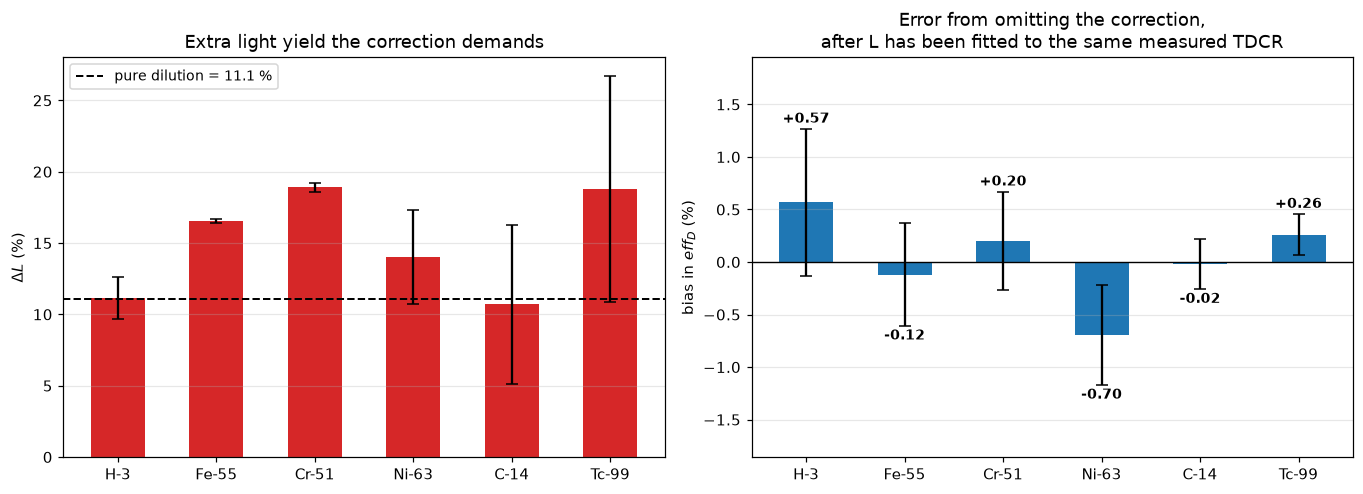

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
x = np.arange(len(NUCLIDES))

axes[0].bar(x, [summary[r]['dL'] for r in NUCLIDES], 0.55, color='#d62728',
            yerr=[summary[r]['udL'] for r in NUCLIDES], capsize=4)
axes[0].axhline(100 * (1 / (1 - FAQ) - 1), color='k', ls='--', lw=1.3,
                label=f'pure dilution = {100*(1/(1-FAQ)-1):.1f} %')
axes[0].set_xticks(x); axes[0].set_xticklabels(NUCLIDES)
axes[0].set_ylabel(r'$\Delta L$ (%)')
axes[0].set_title('Extra light yield the correction demands')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

b = [summary[r]['bias'] for r in NUCLIDES]
ub = [summary[r]['ubias'] for r in NUCLIDES]
axes[1].bar(x, b, 0.55, yerr=ub, capsize=4, color='#1f77b4')
axes[1].axhline(0, color='k', lw=0.9)
axes[1].set_xticks(x); axes[1].set_xticklabels(NUCLIDES)
axes[1].set_ylabel(r'bias in $eff_D$ (%)')
axes[1].set_title('Error from omitting the correction,\nafter L has been '
                  'fitted to the same measured TDCR')
axes[1].grid(axis='y', alpha=0.3)
span = max(abs(min(b)), abs(max(b))) or 1.0
for xi, (v, u) in enumerate(zip(b, ub)):
    axes[1].text(xi, v + (u if v >= 0 else -u) + 0.04 * span * np.sign(v or 1),
                 f'{v:+.2f}', ha='center',
                 va='bottom' if v >= 0 else 'top', fontsize=9,
                 fontweight='bold')
axes[1].margins(y=0.28)

plt.tight_layout()
plt.savefig('micelleCheck_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. What the correction costs

The correction is applied per electron while the decay is being quenched, so
it is paid in the **simulation** pass; a replay just re-reads energies that are
already recorded and costs the same either way. Timing `eff()` would therefore
divide the cost by its replays and report a factor near 1.

This is a separate, smaller run for that reason, and each arm gets a warm-up
call first so that numba's compilation — which is discarded whenever
`set_state()` reloads the module — is not charged to whichever arm happens to
run first.


In [7]:
N_TIME = 3000          # smaller: this is a ratio, it does not need N

timing = {}
print(f'{"nuclide":8s} {"t off (s)":>10s} {"t on (s)":>10s} {"factor":>8s}')
print('-' * 40)
for rad in NUCLIDES:
    t = {}
    for mic in (False, True):
        set_state(mic)
        tm.TDCRPy(2.0, rad, '1', 20, KB, V)          # absorb the JIT here
        t0 = time.time()
        tm.TDCRPy(2.0, rad, '1', N_TIME, KB, V)
        t[mic] = time.time() - t0
    timing[rad] = dict(off=t[False], on=t[True],
                       factor=t[True] / t[False] if t[False] > 0 else np.nan)
    print(f'{rad:8s} {t[False]:10.1f} {t[True]:10.1f} '
          f'{timing[rad]["factor"]:7.2f}x', flush=True)

nuclide   t off (s)   t on (s)   factor
----------------------------------------


H-3             2.1        4.0    1.86x


Fe-55          39.0       65.6    1.68x


Cr-51          40.6       64.4    1.58x


Ni-63           1.2        1.9    1.56x


C-14            0.6        1.7    2.60x


Tc-99           0.6        2.0    3.14x


## 5. Summary

`Delta_L` is the extra light yield the corrected model needs to reproduce the
**same** measured ratio. `Delta_eff_D` is what is left in the efficiency after
that refit — the error you make by reporting the uncorrected number. Both carry
their Monte-Carlo uncertainty, and neither means anything below it.


In [8]:
DIL = 100 * (1 / (1 - FAQ) - 1)

print(f'{"nuclide":8s} {"TDCR":>6s} {"Delta_L %":>10s} {"+-":>6s} '
      f'{"vs dilution":>12s} {"Delta_eff_D %":>14s} {"+-":>6s} '
      f'{"time factor":>12s}')
print('-' * 84)
for rad in NUCLIDES:
    s = summary[rad]
    excess = s['dL'] - DIL
    mark = '' if abs(excess) < 2 * s['udL'] else ('  <-- confinement'
                                                  if excess > 0 else '  <-- ?')
    print(f'{rad:8s} {TD_MEAS[rad]:6.3f} {s["dL"]:10.2f} {s["udL"]:6.2f} '
          f'{excess:+11.2f} {s["bias"]:14.2f} {s["ubias"]:6.2f} '
          f'{timing[rad]["factor"]:11.2f}x{mark}')

print(f'\nDelta_L        extra light yield for the same measured TDCR. Pure')
print(f'               dilution alone needs {DIL:.1f} %; the excess over that is')
print('               confinement -- electrons trapped inside a droplet.')
print('Delta_eff_D    (uncorrected - corrected) / corrected. Positive means the')
print('               efficiency is reported too high, the activity too low.')
print('time factor    simulation pass with the correction / without it.')
print(f'\nAt N = {N} a value smaller than its "+-" is not resolved. Note that')
print('u(Delta_L) grows sharply for the near-saturated nuclides: their modelled')
print('TDCR is almost flat in L, so the ratio barely constrains the fit there.')

print(f'\n{"":14s} {"mean":>10s} {"min":>10s} {"max":>10s}')
arr = np.array([[summary[r]['dL'], summary[r]['bias'], timing[r]['factor']]
                for r in NUCLIDES])
for name, col in zip(('Delta_L %', 'Delta_eff_D %', 'time factor'), arr.T):
    print(f'{name:14s} {col.mean():10.2f} {col.min():10.2f} {col.max():10.2f}')

nuclide    TDCR  Delta_L %     +-  vs dilution  Delta_eff_D %     +-  time factor
------------------------------------------------------------------------------------
H-3       0.668      11.16   1.49       +0.05           0.57   0.70        1.86x
Fe-55     0.570      16.55   0.12       +5.44          -0.12   0.49        1.68x  <-- confinement
Cr-51     0.477      18.91   0.32       +7.79           0.20   0.47        1.58x  <-- confinement
Ni-63     0.881      14.05   3.29       +2.94          -0.70   0.48        1.56x
C-14      0.970      10.72   5.58       -0.39          -0.02   0.24        2.60x
Tc-99     0.980      18.79   7.91       +7.68           0.26   0.20        3.14x

Delta_L        extra light yield for the same measured TDCR. Pure
               dilution alone needs 11.1 %; the excess over that is
               confinement -- electrons trapped inside a droplet.
Delta_eff_D    (uncorrected - corrected) / corrected. Positive means the
               efficiency is reported t

In [9]:
# Restore the configuration this notebook found.
with contextlib.redirect_stdout(io.StringIO()):
    tl.modifyLScocktail(COCKTAIL, NOMINAL['fAq'], 'Water', 0.0)
tl.modifyDiam_micelle(NOMINAL['diam'])
tl.modifySigma_micelle(NOMINAL['sigma'])
tl.modifyMicCorr(NOMINAL['micCorr'])
tl = importlib.reload(tl); tm = importlib.reload(tm)
tl.cleanup_record_files()
print(f'restored: fAq={tl.fAq}, micCorr={tl.micCorr}, '
      f'diam={tl.diam_micelle}, sigma={tl.sigma_micelle}')

restored: fAq=0.1, micCorr=False, diam=4.0, sigma=0.0
